# BME 2301 2026 Project - Midterm Checkin

# Project Analysis

**Student Name or Names:**  Caitlin Bui and Ally Lin 
**Project Title:** Brain Tumor Classification, Analyzing Brain MRI Images 


---

## Part 1 - Project Question

State your current research question clearly: How can we create a model that analyzes MRI medical imaging data to classify and identify different types of brain tumors to support tumor and cancer detection? 
> 

---

### In your dataset or sets, what does one row represent?

> One row represents one MRI brain scan image with a label of the associated tumor category. 

### What does one column represent? (List all appropriate values.)
One column represents a feature/attribute of each brain MRI image. 

> 

### Load and show your dataset(s)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

dataset_path = "C:/Users/CmeKa/OneDrive/Desktop/BiomedicalComputing/Training"

data = [] #The MRI images
labels = [] #The tumor categories

classes = os.listdir(dataset_path)

for label in classes:
    folder = os.path.join(dataset_path, label)

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        image = Image.open(img_path) #Loading the image here 

        data.append(image)
        labels.append(label)

## Part 2 — Cleaning Decisions

Identify and justify at least TWO cleaning decisions.

---

### Cleaning Decision 1

What was the issue? 
The MRI images have different image sizes. Having different image sizes could cause issues with the training set, and will also prevent us from being able to convert them into a NumPy array, so it is important to have consistent image sizes in our data. 

What did you do? 
We resized all of the images in the data to 128 x 128 pixel size. 

How might this affect results?
Resizing the images will help the model we create to compare images consistently, leading to a more efficient model. 

---

### Cleaning Decision 2

What was the issue?
Images have different colors, making the data harder to classify and less consistent. 

What did you do?
We converted the images to grayscale and made all images use the same color representation. 

How might this affect results?
This will make it easier for the model to classify since we are removing noise from the different colorings in the images. 

In [2]:
# show cleaning steps here
cleaned_data = []

for image in data:
    
    image = image.convert("L") #converting the images to grayscale
    image = image.resize((128,128)) #resizing all image size to 128 x 128
    
    cleaned_data.append(np.array(image))

cleaned_data = np.array(cleaned_data)
labels = np.array(labels)

print(cleaned_data.shape)

(5600, 128, 128)


## Part 3 - Exploratory Visualization

What variable or other feature are you visualizing?
We are visualizing the MRI brain images from different tumor categories. 

Why? 
We want to visually see the differences between each of the tumor types through the MRI brain images. We want to see key differences between the tumor types before creating a model to classify them.  

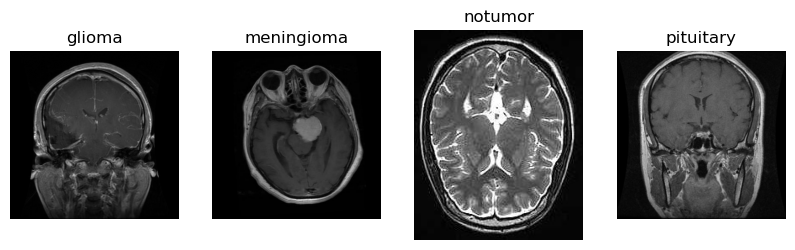

In [3]:
# viz code goes here

#Showing an Brain MRI image of each category
plt.figure(figsize=(10,4))

plt.subplot(1,4,1)
plt.imshow(data[0], cmap="gray")
plt.title(labels[0])
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(data[1400], cmap="gray")
plt.title(labels[1400])
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(data[2800], cmap="gray")
plt.title(labels[2800])
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(data[4200], cmap="gray")
plt.title(labels[4200])
plt.axis("off")

plt.show()

### Other visualization directly related to your project

In [5]:
# create a plot that directly supports your main project question

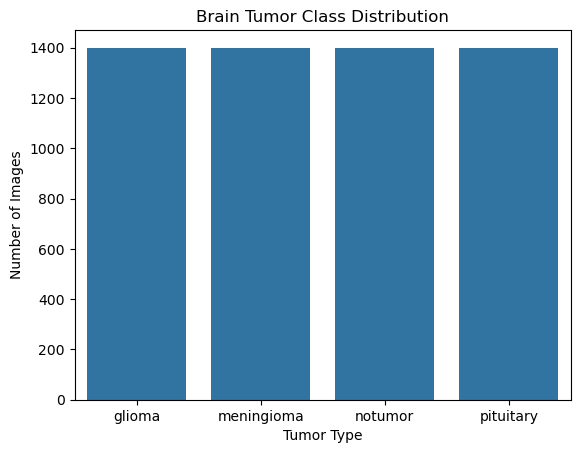

In [6]:
sns.countplot(x = labels)
plt.title("Brain Tumor Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.show()

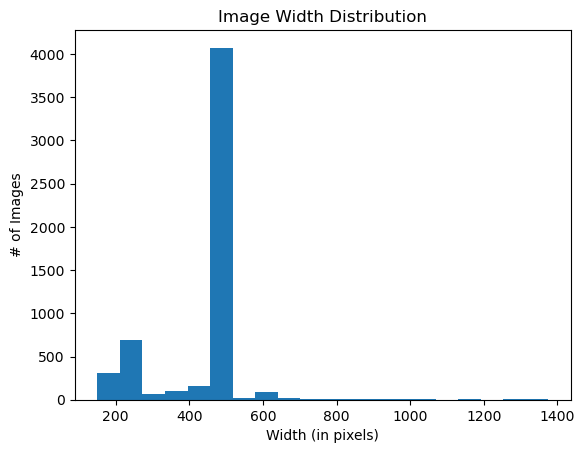

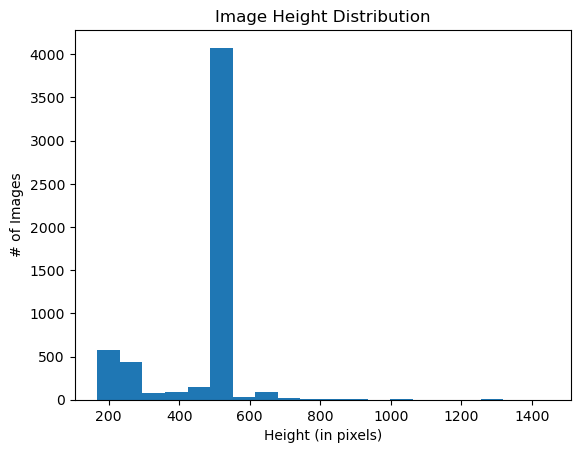

In [4]:
sizes = [img.size for img in data]

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.hist(widths, bins = 20)
plt.title("Image Width Distribution")
plt.xlabel("Width (in pixels)")
plt.ylabel("# of Images")
plt.show()

plt.hist(heights, bins = 20)
plt.title("Image Height Distribution")
plt.xlabel("Height (in pixels)")
plt.ylabel("# of Images")
plt.show()

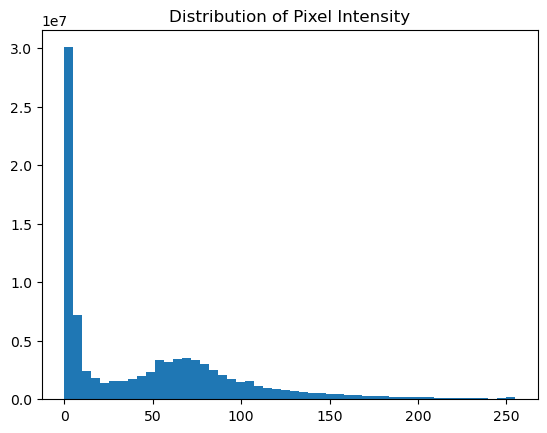

In [7]:
plt.hist(cleaned_data.flatten(), bins=50) #https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html 
plt.title("Distribution of Pixel Intensity")
plt.show()

## Part 4 - Statistical and/or Epidemiological Analysis

In [6]:
# show at least one statistical and/or epidemiological analysis here

In [8]:
#Summary Statistics of the MRI Images 
pixels = cleaned_data.flatten()
df = pd.DataFrame(pixels, columns=["pixel_intensity"])
print(df.describe())

       pixel_intensity
count     9.175040e+07
mean      4.690623e+01
std       5.027513e+01
min       0.000000e+00
25%       3.000000e+00
50%       3.500000e+01
75%       7.600000e+01
max       2.550000e+02


## Part 5 - Assumptions and Limitations
Identify at least three assumptions underlying your analysis.

1.

2.

3.

For each:
- Why does it matter?
- What happens if it is violated?

2.6 Part 6 - Reflection and Next Steps

Discuss what you've learned so far and what you plan to do next.